<a href="https://colab.research.google.com/github/xbanuelos/BI-Portfolio/blob/main/phase_01/project_03_peak_hours/peak_hours_heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 03 — Peak Hours Heatmap by City Zone
**Dataset:** Olist Brazilian E-Commerce (Kaggle)

**Domain variant:** ER Admission Heatmap by hour and day of week

**Business Questions**
1. What hours of the day have the highest order volume?

Peak hours are 14h-16h, with Tuesday 14h beigng the single highest slot (1,124 orders). A secondary peak appears at 21h on Monday (1,118 orders), suggesting two distinct buying moments:

post-lunch and after-dinner browsing.

2. What days of the week are busiest?

Monday and Tusday dominate the top 5 slots. Monday has the most consistent high volume throughout the day while Tuesday has the single highest peak moment.

3. Are there specific hour x day combinations that spike?

TOP 5:
Tue - 14h, Mon - 21h, Mon - 14h, Mon - 16h, Tue 16 h. All concentrated in the 14-16 window on weekdays.

4. Do peak patterns differ by customer state?

Yes. While all states show higher weekdays volume, the peak hour varies by region:

| state | day     | hour | order|

|  SP   | tuesday | 14h  |  483 |

|  RJ   | tuesday | 14h  |  162 |

|  MG   | thursday| 16h  |  140 |

|  RS   | sunday  | 20h  |  75  |

|  PR   | monday  | 10h  |  69  |

SP and RJ share the same peak slot (Tue 14h) but SP has 3x the volume. RS is the only state with a weekend peak.


## Project Conclusion

Demand in Olist peaks nationally between 13h - 16h on weekdays, with Tuesday 14h as the single highest slot. Regional behaviour differs - SP/RJ peak at lunch, MG in the evening, and RS is the only state with a dominant weekend peak (sunday 20h).

Late night orders (0h, 19-23h) show the highest late rates (~8.7%), suggesting that purchase timing affects delivery performance.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

order_items = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_order_items_dataset.csv')
order_payments = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_order_reviews_dataset.csv')
order = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_orders_dataset.csv')
customers = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_customers_dataset.csv')
products = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_products_dataset.csv')
cat_translation = pd.read_csv('/content/drive/MyDrive/BI Portfolio/product_category_name_translation.csv')
sellers = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_sellers_dataset.csv')
geolocation = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_geolocation_dataset.csv')

In [31]:
order.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date']

In [32]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

order[date_columns] = order[date_columns].apply(pd.to_datetime)

In [33]:
#Extraer hora y día de la semana
order['hour'] = order['order_purchase_timestamp'].dt.hour
order['day_of_week'] = order['order_purchase_timestamp'].dt.day_name()

In [34]:
#Orden correcto de los días
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

#Matriz hora x día
heatmap_matrix = order.groupby(['day_of_week','hour'])['order_id'].count().unstack(fill_value=0)

#reordenar días
heatmap_matrix = heatmap_matrix.reindex(day_order)
print(heatmap_matrix.shape) # debe de ser 7 x 24 (7 días de la semana x 24 horas)

(7, 24)


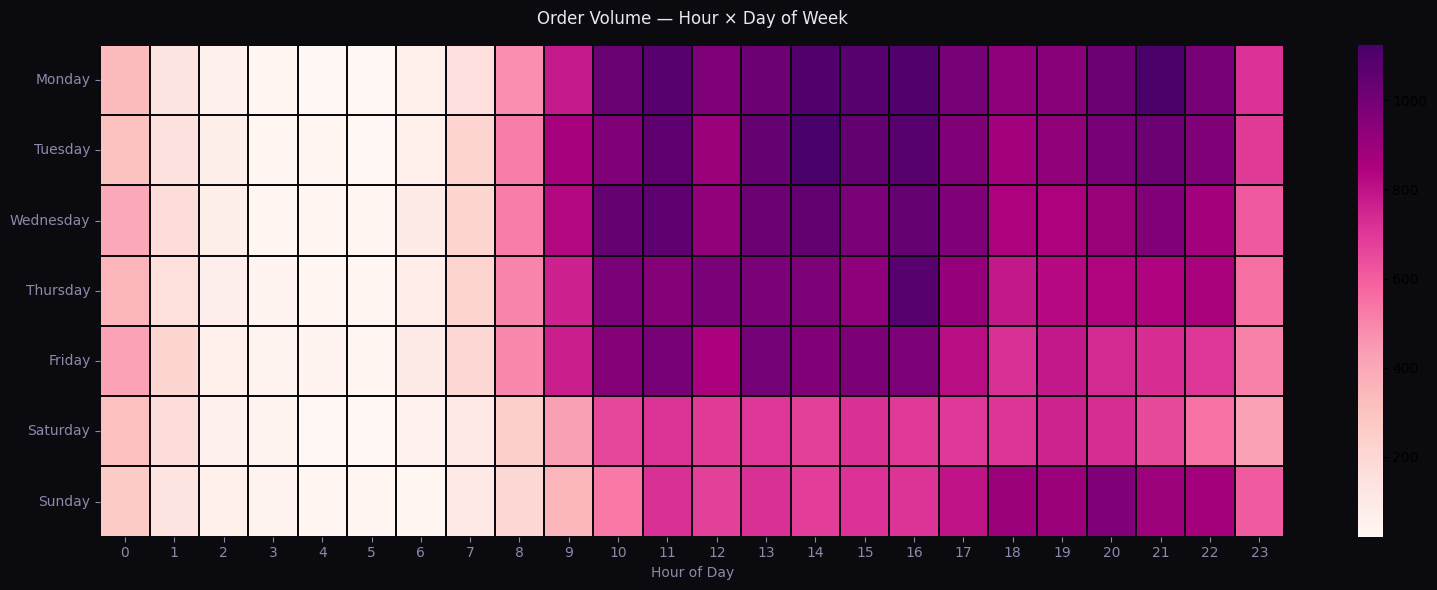

In [35]:
fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(heatmap_matrix,
            cmap='RdPu',
            annot=False,
            linewidths=0.3,
            linecolor='#0a0a0f',
            ax=ax)

ax.set_title('Order Volume — Hour × Day of Week', color='#e8e8f0', pad=15)
ax.set_xlabel('Hour of Day', color='#8a8aaa')
ax.set_ylabel('')
ax.tick_params(colors='#8a8aaa')
fig.patch.set_facecolor('#0a0a0f')
ax.set_facecolor('#0a0a0f')

plt.tight_layout()
plt.show()

In [36]:
# Top 5 combinaciones hora x día
top_combos = order.groupby(['day_of_week', 'hour'])['order_id']\
                   .count().reset_index()\
                   .sort_values('order_id', ascending=False)\
                   .head(5)

print(top_combos)

    day_of_week  hour  order_id
134     Tuesday    14      1124
45       Monday    21      1118
38       Monday    14      1096
40       Monday    16      1094
136     Tuesday    16      1081


In [37]:
customers.columns.tolist()

['customer_id',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state']

In [42]:
# Verificar que los customer_id coincidan entre los dos dfs
print(order['customer_id'].dtype)
print(customers['customer_id'].dtype)

# Ver si hay matches
matches = order['customer_id'].isin(customers['customer_id']).sum()
print(f"Matches: {matches}")

object
object
Matches: 99441


In [43]:
# Paso 1 — merge limpio
state_orders = order.merge(customers[['customer_id', 'customer_state']],
                           on='customer_id', how='left')
print(state_orders.shape)
print(state_orders['customer_state'].value_counts().head(5))

(99441, 11)
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
Name: count, dtype: int64


In [44]:
# Paso 2 — calcular top 5 DESPUÉS del merge
top_5_states = state_orders['customer_state'].value_counts().head(5).index

# Paso 3 — filtrar
state_orders_filtered = state_orders[state_orders['customer_state'].isin(top_5_states)]
print(state_orders_filtered.shape)

(76744, 11)


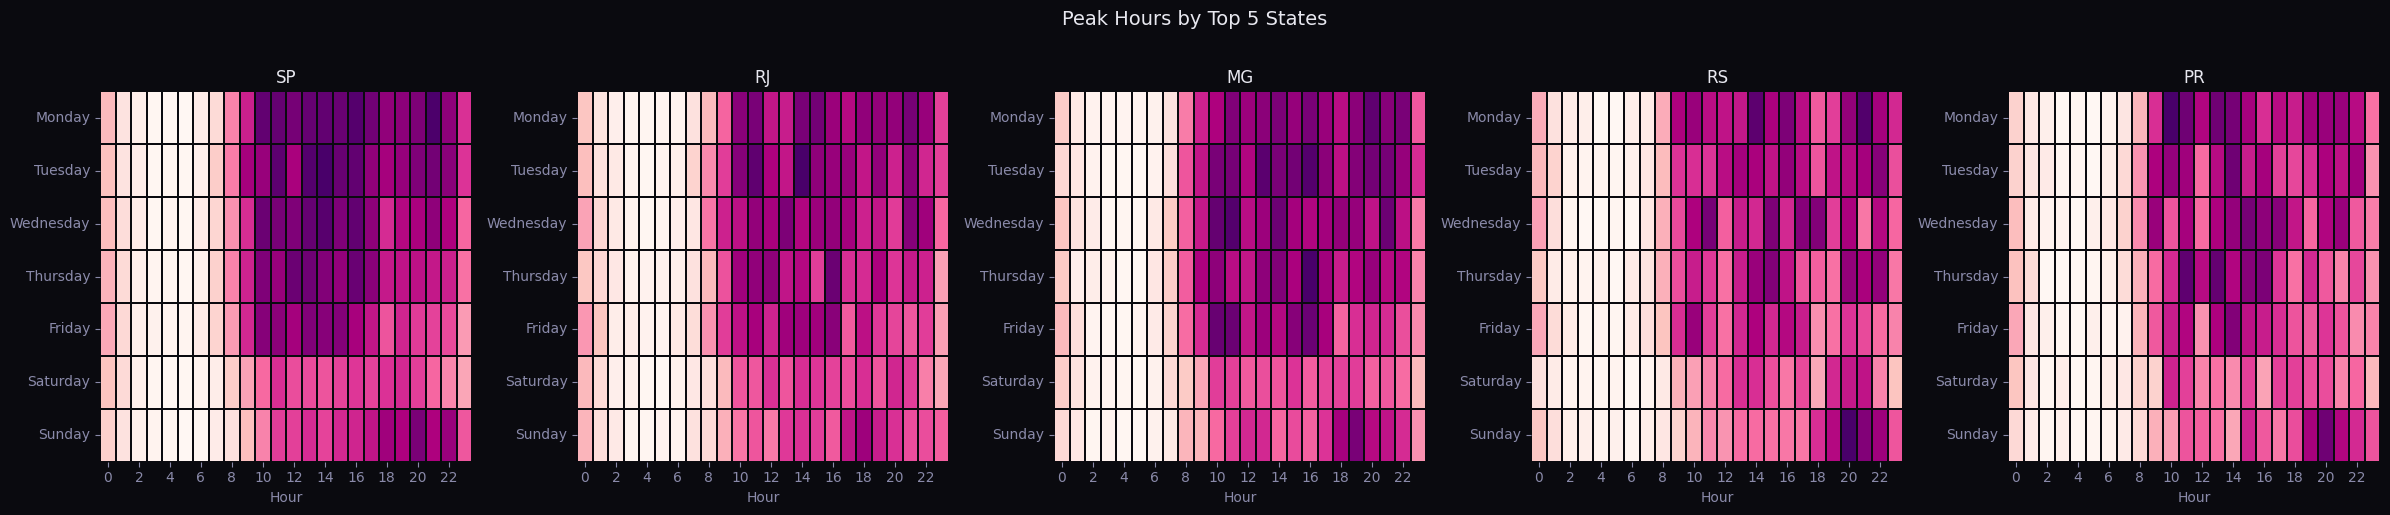

In [47]:
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
fig.patch.set_facecolor('#0a0a0f')

for ax, state in zip(axes, top_5_states):
    matrix = state_orders_filtered[state_orders_filtered['customer_state'] == state]\
             .groupby(['day_of_week', 'hour'])['order_id']\
             .count().unstack(fill_value=0)\
             .reindex(day_order).fillna(0)

    sns.heatmap(matrix, cmap='RdPu', annot=False,
                linewidths=0.3, linecolor='#0a0a0f',
                ax=ax, cbar=False)  # sin vmin/vmax

    ax.set_title(state, color='#e8e8f0')
    ax.set_xlabel('Hour', color='#8a8aaa')
    ax.set_ylabel('')
    ax.tick_params(colors='#8a8aaa')
    ax.set_facecolor('#0a0a0f')

plt.suptitle('Peak Hours by Top 5 States', color='#e8e8f0', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [49]:
# Top 5 combinaciones hora x día x estado
top_combos_state = state_orders_filtered.groupby(['customer_state','day_of_week', 'hour'])['order_id']\
                   .count().reset_index()\
                   .sort_values('order_id', ascending=False)\
                   .groupby('customer_state').first().reset_index()

print(top_combos_state)

  customer_state day_of_week  hour  order_id
0             MG    Thursday    16       140
1             PR      Monday    10        69
2             RJ     Tuesday    14       162
3             RS      Sunday    20        75
4             SP     Tuesday    14       483


In [52]:
delivered = order[order['order_status'] == 'delivered'].copy()
delivered['is_late'] = delivered['order_estimated_delivery_date'] <  delivered['order_delivered_customer_date']

In [55]:
#peak hours late delivery rate
peak_late = order.merge(delivered[['order_id','is_late']],on='order_id',how='left')

In [59]:
#late rate por hora
late_by_hour = peak_late.groupby('hour').agg(
    total=('order_id', 'count'),
    late=('is_late', 'sum')
).reset_index()

late_by_hour['late_rate'] = (late_by_hour['late'] /
                              late_by_hour['total'] * 100).round(1)

print(late_by_hour.sort_values('late_rate', ascending=False).head(10))

    hour  total late late_rate
0      0   2394  209  8.730159
21    21   6217  538  8.653691
23    23   4123  353  8.561727
19    19   5982  495  8.274824
22    22   5816  481  8.270289
12    12   5995  494    8.2402
1      1   1170   95  8.119658
14    14   6569  526  8.007307
20    20   6193  492  7.944453
16    16   6675  528  7.910112


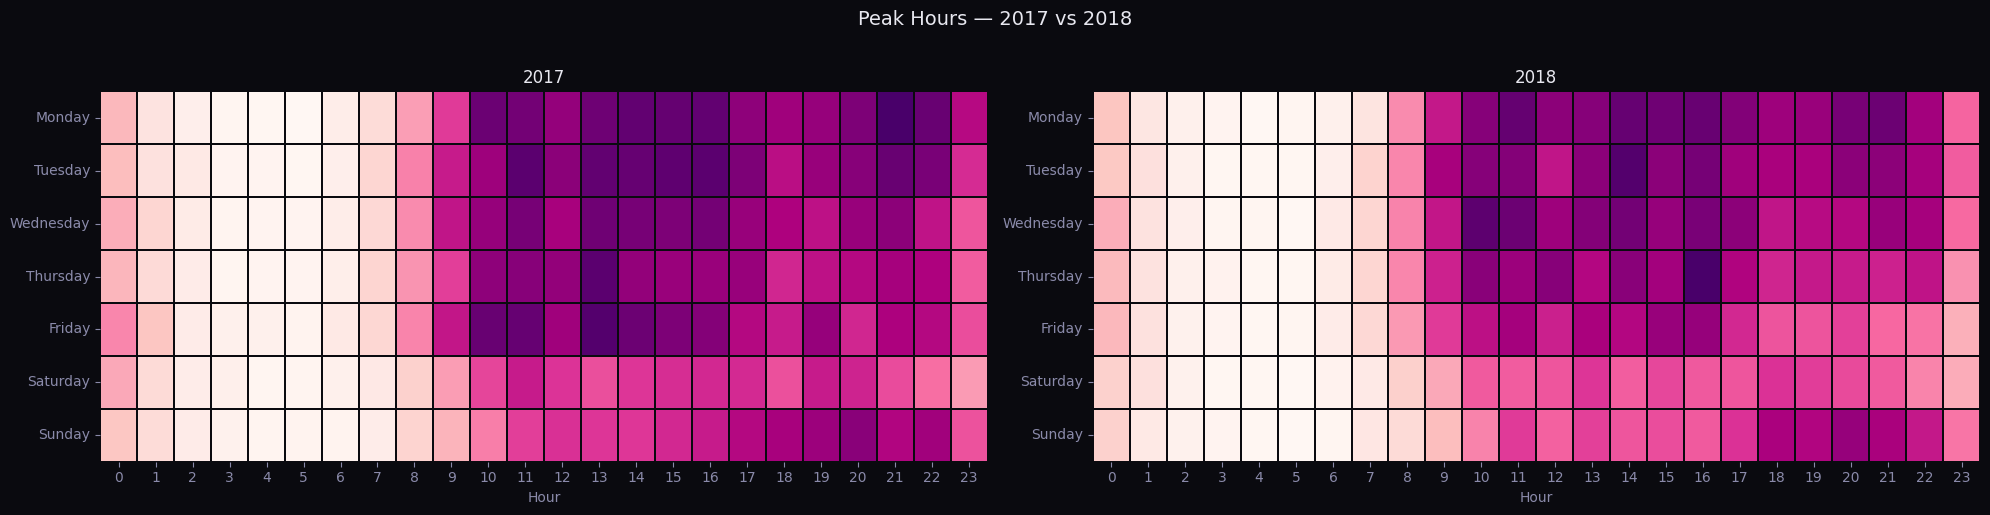

In [60]:
#tendencias entre 2017 vs 2018
order['year'] = order['order_purchase_timestamp'].dt.year

# Matriz por año
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
fig.patch.set_facecolor('#0a0a0f')

for ax, year in zip(axes, [2017, 2018]):
    matrix = order[order['year'] == year]\
             .groupby(['day_of_week', 'hour'])['order_id']\
             .count().unstack(fill_value=0)\
             .reindex(day_order).fillna(0)

    sns.heatmap(matrix, cmap='RdPu', annot=False,
                linewidths=0.3, linecolor='#0a0a0f',
                ax=ax, cbar=False)

    ax.set_title(str(year), color='#e8e8f0')
    ax.set_xlabel('Hour', color='#8a8aaa')
    ax.set_ylabel('')
    ax.tick_params(colors='#8a8aaa')
    ax.set_facecolor('#0a0a0f')

plt.suptitle('Peak Hours — 2017 vs 2018', color='#e8e8f0', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [62]:
#27 states analysis x time x day

# Todos los estados
all_states = state_orders['customer_state'].unique()

# Peak slot por cada estado
peak_by_state = state_orders.groupby(['customer_state', 'day_of_week', 'hour'])['order_id']\
                    .count().reset_index()\
                    .sort_values('order_id', ascending=False)\
                    .groupby('customer_state').first().reset_index()\
                    .sort_values('order_id', ascending=False)

print(peak_by_state)

   customer_state day_of_week  hour  order_id
25             SP     Tuesday    14       483
18             RJ     Tuesday    14       162
10             MG    Thursday    16       140
22             RS      Sunday    20        75
17             PR      Monday    10        69
23             SC      Sunday    20        54
4              BA      Monday    21        45
6              DF      Monday    16        35
8              GO   Wednesday    10        35
7              ES      Monday    14        30
15             PE      Monday    22        27
5              CE      Monday    12        19
12             MT      Friday    13        18
9              MA      Monday    16        16
13             PA      Monday    13        16
11             MS   Wednesday    16        15
16             PI    Thursday    10        11
19             RN      Monday    16        11
1              AL      Friday    13        11
14             PB    Thursday    10        10
26             TO      Monday    1